### Traitement des données : Dans cette partie, il s'agira pour nous de préparer les données pour la modélisation à travers le nettoyage, l'encodage et le feature engineering

In [25]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import OrdinalEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
import os
os.listdir("../data/raw")

['smart_city_traffic_stress_dataset.csv']

In [27]:
# Charging the dataset
data = pd.read_csv("../data/raw/smart_city_traffic_stress_dataset.csv")

In [28]:
# Types of columns in the dataset
data.dtypes

traffic_density              int64
horn_events_per_min        float64
avg_speed                  float64
signal_wait_time           float64
weather_condition           object
road_quality_score         float64
driver_experience_level     object
stress_index               float64
dtype: object

In [29]:
# Checking missing values
data.isnull().sum()

traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

In [30]:
# Visualization of the first 3 rows of the dataset 
data.head(3)

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02


In [31]:
# Checking for duplicates
print(data.duplicated().sum())

0


### Encodage

In [32]:
# Encoding categorial variable driver_experience_level with OrdinalEncoder
oe = OrdinalEncoder(categories=[['Beginner', 'Intermediate', 'Expert']])
data['driver_experience_encoded'] = oe.fit_transform(data[['driver_experience_level']])
data.drop(columns=['driver_experience_level'], inplace=True)

# Verification
print(data[['driver_experience_encoded']].value_counts().sort_index())

driver_experience_encoded
0.0                          14872
1.0                          24980
2.0                          10148
Name: count, dtype: int64


In [33]:
# Encoding categorial variable weather_condition with OneHotEncoding
data = pd.get_dummies(data, columns=['weather_condition'], prefix='weather', drop_first=True)

# Verification
weather_cols = [c for c in data.columns if c.startswith('weather_')]
data[weather_cols] = data[weather_cols].astype(int)
print(data[weather_cols].head())
print(data[weather_cols].value_counts())

   weather_Foggy  weather_Hot  weather_Rainy
0              1            0              0
1              0            0              1
2              0            0              0
3              0            0              0
4              0            0              0
weather_Foggy  weather_Hot  weather_Rainy
0              0            0                25018
                            1                12283
1              0            0                 7615
0              1            0                 5084
Name: count, dtype: int64


In [34]:
# Global verification
print(f"Taille avant encodage : (50000, 8)")
print(f"Taille après encodage : {data.shape}")
print("\nColonnes finales :")
print(data.dtypes)

Taille avant encodage : (50000, 8)
Taille après encodage : (50000, 10)

Colonnes finales :
traffic_density                int64
horn_events_per_min          float64
avg_speed                    float64
signal_wait_time             float64
road_quality_score           float64
stress_index                 float64
driver_experience_encoded    float64
weather_Foggy                  int64
weather_Hot                    int64
weather_Rainy                  int64
dtype: object


In [35]:
# Correlations of new features with stress_index
new_features = ['driver_experience_encoded', 'weather_Foggy', 'weather_Hot', 'weather_Rainy']
print("Corrélations avec stress_index :")
print(data[new_features + ['stress_index']].corr()['stress_index'].sort_values(ascending=False).round(3))

Corrélations avec stress_index :
stress_index                 1.000
weather_Foggy                0.012
weather_Rainy                0.010
weather_Hot                 -0.003
driver_experience_encoded   -0.325
Name: stress_index, dtype: float64


### Feature Engineering

In [36]:
# 1. Congestion score — interaction densité × attente
# Capture les situations vraiment bloquées (dense ET long)
data['congestion_score'] = (data['traffic_density'] * data['signal_wait_time']) / 100

# 2. Horn density — klaxons relatifs à la densité
# Mesure le comportement agressif des conducteurs, pas le volume brut
data['horn_density'] = data['horn_events_per_min'] / (data['traffic_density'] + 1)

# 3. Speed efficiency — vitesse relative à la densité
# Détecte les anomalies : vitesse trop haute ou trop basse pour la densité observée
data['speed_efficiency'] = data['avg_speed'] / (data['traffic_density'] + 1)

In [37]:
# Global verification
print(f"Taille avant feature engineering : (50000, 10)")
print(f"Taille après feature engineering : {data.shape}")
print("\nColonnes finales :")
print(data.dtypes)

Taille avant feature engineering : (50000, 10)
Taille après feature engineering : (50000, 13)

Colonnes finales :
traffic_density                int64
horn_events_per_min          float64
avg_speed                    float64
signal_wait_time             float64
road_quality_score           float64
stress_index                 float64
driver_experience_encoded    float64
weather_Foggy                  int64
weather_Hot                    int64
weather_Rainy                  int64
congestion_score             float64
horn_density                 float64
speed_efficiency             float64
dtype: object


In [38]:
# Correlations of new features with stress_index
new_features = ['congestion_score', 'horn_density', 'speed_efficiency']
print("Corrélations avec stress_index :")
print(data[new_features + ['stress_index']].corr()['stress_index'].sort_values(ascending=False).round(3))

Corrélations avec stress_index :
stress_index        1.000
congestion_score    0.835
horn_density       -0.169
speed_efficiency   -0.705
Name: stress_index, dtype: float64


### Réglages Multicolinéarité

In [39]:
# VIF of Numericals Features 
def compute_vif(df):
    vif = pd.DataFrame()
    vif['feature'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values('VIF', ascending=False).round(2)

# Numericals Features before feature engineering
num_features = ['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'road_quality_score', 'driver_experience_encoded']
all_features = num_features + ['congestion_score', 'horn_density', 'speed_efficiency']

print("\n================ VIF ================")
print(compute_vif(data[all_features]))


================ VIF ================


                     feature     VIF
0            traffic_density  269.48
3           signal_wait_time  239.24
6           congestion_score  135.72
2                  avg_speed   74.34
1        horn_events_per_min   39.19
4         road_quality_score   16.59
8           speed_efficiency   15.53
7               horn_density   15.27
5  driver_experience_encoded    2.66


In [40]:
# Deleting original features
features_to_drop = ['horn_events_per_min', 'signal_wait_time', 'traffic_density']
data.drop(columns=features_to_drop, inplace=True)

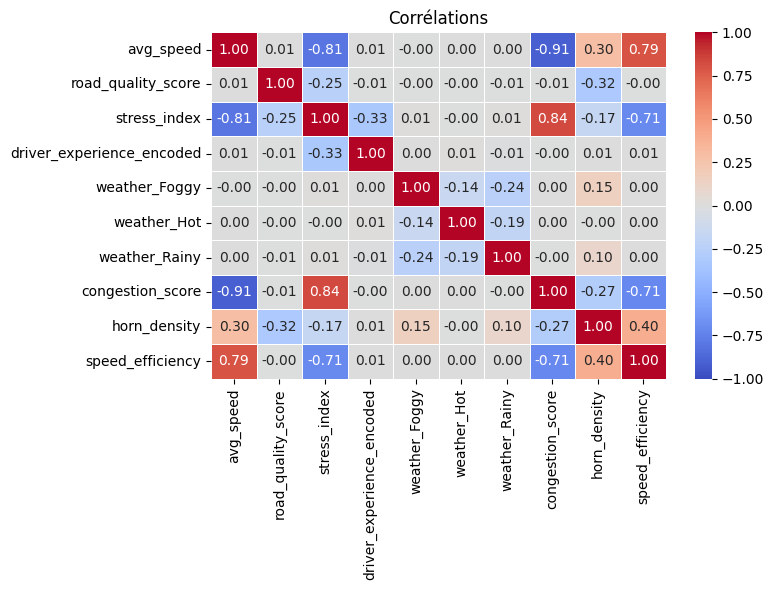

In [41]:
# Heatmap Correlation for verification
plt.figure(figsize=(8, 6))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Corrélations')
plt.tight_layout()
plt.savefig('../results/figures/correlation_after_vif.png', dpi=150)
plt.show()

In [42]:
# Let's split the dataset to prepare modelisation with linear model or not
data_lin = data.drop(columns=['avg_speed', 'speed_efficiency', 'weather_Foggy', 'weather_Hot', 'weather_Rainy', 'horn_density'])
data_boost = data.drop(columns=['speed_efficiency'])

In [43]:
# VIF après suppression des features redondantes
remaining = ['avg_speed', 'road_quality_score', 'driver_experience_encoded',
             'congestion_score', 'horn_density', 'speed_efficiency']
print("=== VIF après suppression ===")
print(compute_vif(data[remaining]))
# Attendu : road_quality_score doit être redescendue sous 5

=== VIF après suppression ===
                     feature    VIF
0                  avg_speed  23.09
1         road_quality_score  14.69
4               horn_density   6.17
5           speed_efficiency   5.21
3           congestion_score   4.25
2  driver_experience_encoded   2.65


##### === DECISION VIF data_boost ===

avg_speed        VIF=23.09  -> élevé MAIS accepté
road_quality     VIF=14.69  -> élevé MAIS accepté

Raison : data_boost est réservé aux modèles à base d'arbres
(RandomForest, XGBoost, LightGBM).

Ces modèles font des splits binaires indépendants à chaque nœud -
ils ne calculent pas de coefficients comme la régression linéaire.
La multicolinéarité ne biaise pas leurs prédictions, elle réduit
simplement la stabilité de la feature importance (deux features
corrélées se "partagent" l'importance) mais n'affecte pas le R².

-> Le VIF strict (< 5) est une contrainte pour la régression UNIQUEMENT.    
-> Pour data_boost : VIF informatif seulement, pas bloquant.

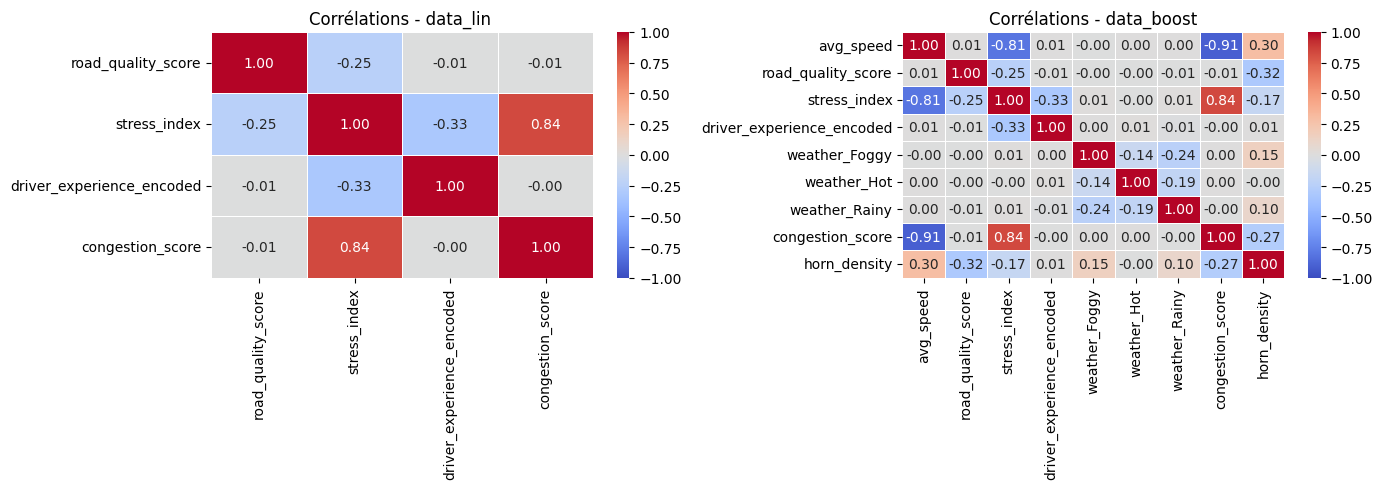

In [44]:
# Final correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap data_lin
corr_lin = data_lin.corr()
sns.heatmap(corr_lin, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Corrélations - data_lin ', fontsize=12)

# Heatmap data_boost
corr_boost = data_boost.corr()
sns.heatmap(corr_boost, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Corrélations - data_boost', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/correlation_lin_vs_boost.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# VIF of data_lin
data_lin_features = ['congestion_score', 'driver_experience_encoded', 'road_quality_score']
print(compute_vif(data_lin[data_lin_features]))

                     feature   VIF
2         road_quality_score  3.50
1  driver_experience_encoded  2.41
0           congestion_score  2.40


In [46]:
# Save the ordinal encoder for driver_experience_level to encode it on new data
with open("../models/ordinal_encoder.pkl", "wb") as f:
    pickle.dump(oe, f)
print("ordinal_encoder.pkl sauvegardé pour driver_experience_level.")

ordinal_encoder.pkl sauvegardé pour driver_experience_level.


In [47]:
# Save
data_lin.to_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_lin.csv", index=False)
data_boost.to_csv("../data/processed/smart-city-traffic-stress-index-dataset_clean_boost.csv", index=False)
print("Saved!")

Saved!


### **Conclusion**

 **ENCODAGE**   
  ✓  driver_experience_level -> OrdinalEncoder (0=Beginner, 1=Inter, 2=Expert)  
  ✓  weather_condition       -> One-Hot (drop_first=True -> 3 colonnes int)  
 
 **FEATURE ENGINEERING**   
  ✓  congestion_score  = traffic_density × signal_wait_time / 100 -> r=+0.835  
  ~  horn_density      = horn/density                              -> r=-0.169  
  ~  speed_efficiency  = avg_speed/density                         -> r=-0.705  
  ->  congestion_score retenu comme feature composite principale   

 **MULTICOLINÉARITÉ (VIF)**  
  Supprimées : traffic_density, signal_wait_time, horn_events_per_min   
  data_lin VIF : congestion=2.40, experience=2.41, road_quality=3.50   

 **DATASETS FINAUX**   
  **data_lin (50000 × 4)** : congestion_score, driver_experience, road_quality_score + stress_index  
  **data_boost (50000 × 9)** : congestion_score, driver_experience, road_quality_score, avg_speed, horn_density, weather_* + stress_index    

 **PROCHAINE ÉTAPE : MODÉLISATION**   
  Le notebook 03_modeling.ipynb entraînera et comparera :  
  • LinearRegression     sur data_lin  (benchmark)  
  • RandomForest         sur data_boost  
  • XGBoost              sur data_boost  
  • LightGBM             sur data_boost  
  Évaluation via RMSE, MAE, R² 